In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#How to Find null values

In [4]:
data = pd.read_csv("Diabetes Missing data.csv")

In [3]:
data.head(5)

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [9]:
data.shape

(768, 9)

In [4]:
data.isnull().sum()

Pregnant               0
Glucose                5
Diastolic_BP          35
Skin_Fold            227
Serum_Insulin        374
BMI                   11
Diabetes_Pedigree      0
Age                    0
Class                  0
dtype: int64

In [5]:
data.isnull().sum().sum()

np.int64(652)

In [10]:
(data.isnull().sum()/data.shape[0])*100

Pregnant              0.000000
Glucose               0.651042
Diastolic_BP          4.557292
Skin_Fold            29.557292
Serum_Insulin        48.697917
BMI                   1.432292
Diabetes_Pedigree     0.000000
Age                   0.000000
Class                 0.000000
dtype: float64

In [6]:
(data.isnull().sum().sum()/(data.shape[0]*data.shape[1]))*100

np.float64(9.43287037037037)

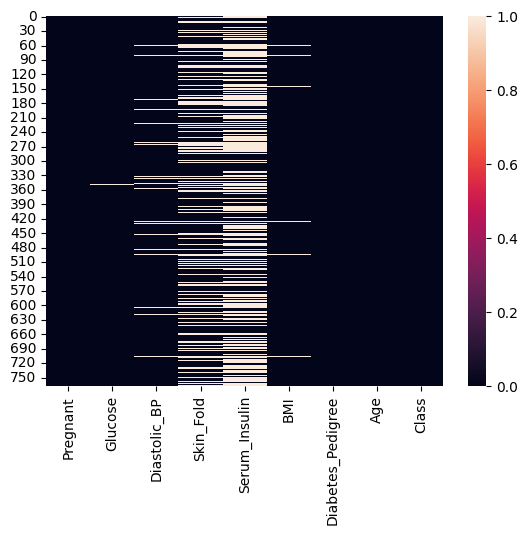

In [13]:
#Graphical representation of null values

sns.heatmap(data.isnull())
plt.show()

In [10]:
#Dropping colunm which have large ammount of null values

data.drop(columns = ["Serum_Insulin"] , inplace = True)

In [11]:
#Dropping raws having null values

data.dropna(inplace=True) 

In [12]:
data.shape

(532, 8)

In [13]:
# % of dropping null values

((768-532)/768)*100

30.729166666666668

In [15]:
data.isnull().sum()

Pregnant             0
Glucose              0
Diastolic_BP         0
Skin_Fold            0
BMI                  0
Diabetes_Pedigree    0
Age                  0
Class                0
dtype: int64

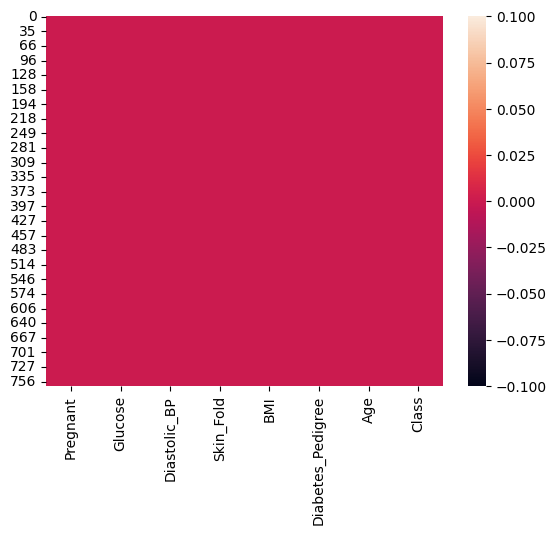

In [16]:
#graphical representation

sns.heatmap(data.isnull())
plt.show()

In [3]:
#Fill null values

df = pd.read_csv("Diabetes Missing data.csv")

In [4]:
df.head(5)

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [14]:
#backword fill and forward fill (ffill) , axis means forward right and forward left fill

df = df.fillna(method = "bfill",axis = 1)

C:\Users\DELL\AppData\Local\Temp\ipykernel_1800\3690421857.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method = "bfill",axis = 1)


In [15]:
df.isnull().sum()

Pregnant             0
Glucose              0
Diastolic_BP         0
Skin_Fold            0
Serum_Insulin        0
BMI                  0
Diabetes_Pedigree    0
Age                  0
Class                0
dtype: int64

#Filling caregorical data using mode 

#specific column mode filling

dataframe["Gender"].fillna(dataframe["Gender"].mode()[0], inplace = True)

#fill whole dataset with mode

for i in dataframe.select_dtype(include ="object").columns:
    dataframe[i].fillna(dataframe[i].mode()[0] , inplace = True)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns
import numpy as np

In [2]:
Df = pd.read_csv("Diabetes Missing Data.csv")

In [3]:
Df.head(5)

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [4]:
Df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pregnant           768 non-null    int64  
 1   Glucose            763 non-null    float64
 2   Diastolic_BP       733 non-null    float64
 3   Skin_Fold          541 non-null    float64
 4   Serum_Insulin      394 non-null    float64
 5   BMI                757 non-null    float64
 6   Diabetes_Pedigree  768 non-null    float64
 7   Age                768 non-null    int64  
 8   Class              768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [5]:
Df.shape

(768, 9)

In [6]:
Df.select_dtypes(include = "float64").columns

Index(['Glucose', 'Diastolic_BP', 'Skin_Fold', 'Serum_Insulin', 'BMI',
       'Diabetes_Pedigree'],
      dtype='object')

In [8]:
si = SimpleImputer(strategy = "mean")
arr = si.fit_transform(Df[['Glucose', 'Diastolic_BP', 'Skin_Fold', 'Serum_Insulin', 'BMI',
       'Diabetes_Pedigree']])

In [9]:
arr

array([[148.        ,  72.        ,  35.        , 155.54822335,
         33.6       ,   0.627     ],
       [ 85.        ,  66.        ,  29.        , 155.54822335,
         26.6       ,   0.351     ],
       [183.        ,  64.        ,  29.15341959, 155.54822335,
         23.3       ,   0.672     ],
       ...,
       [121.        ,  72.        ,  23.        , 112.        ,
         26.2       ,   0.245     ],
       [126.        ,  60.        ,  29.15341959, 155.54822335,
         30.1       ,   0.349     ],
       [ 93.        ,  70.        ,  31.        , 155.54822335,
         30.4       ,   0.315     ]])

In [12]:
new_data = pd.DataFrame(arr,columns = Df.select_dtypes(include = "float64").columns)

In [13]:
new_data.head()

,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree
0,148.0,72.0,35.00000,155.548223,33.6,0.627
1,85.0,66.0,29.00000,155.548223,26.6,0.351
2,183.0,64.0,29.15342,155.548223,23.3,0.672
3,89.0,66.0,23.00000,94.000000,28.1,0.167
4,137.0,40.0,35.00000,168.000000,43.1,2.288
